<a href="https://colab.research.google.com/github/gaurvraj/Analysis-of-Superstore/blob/main/Superstore_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Upload Dataset**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


# **Load & Clean Data**

In [2]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Clean column names
df.columns = df.columns.str.replace(' ', '_')

# Convert dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

# Check data
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Basic **Overview**

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9994 non-null   int64         
 1   Order_ID       9994 non-null   object        
 2   Order_Date     9994 non-null   datetime64[ns]
 3   Ship_Date      9994 non-null   datetime64[ns]
 4   Ship_Mode      9994 non-null   object        
 5   Customer_ID    9994 non-null   object        
 6   Customer_Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal_Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product_ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# SQL Analysis (Inside Colab)**bold text**

In [4]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

query = """
SELECT Region, SUM(Sales) as total_sales, SUM(Profit) as total_profit
FROM sales
GROUP BY Region
ORDER BY total_profit DESC;
"""

pd.read_sql(query, conn)

,Region,total_sales,total_profit
0,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,Central,501239.8908,39706.3625


# Discount vs **Profit**

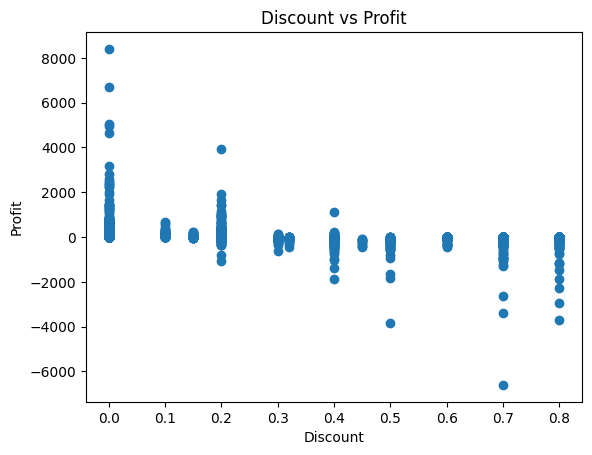

In [5]:
import matplotlib.pyplot as plt

plt.scatter(df['Discount'], df['Profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

# Loss-Making **Products**

In [7]:
loss_products = df[df['Profit'] < 0]

loss_products.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)

,Profit
Sub-Category,
Binders,-38510.4964
Tables,-32412.1483
Machines,-30118.6682
Bookcases,-12152.2060
Chairs,-9880.8413
Appliances,-8629.6412
Phones,-7530.6235
Furnishings,-6490.9134
Storage,-6426.3038


# Top Customers (Pareto)**bold text**

In [8]:
top_customers = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False)

top_customers.head(10)

,Sales
Customer_Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


# Category **Performance**

In [9]:
df.groupby('Category')[['Sales','Profit']].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [10]:
df.to_csv('cleaned_superstore.csv', index=False)

from google.colab import files
files.download('cleaned_superstore.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>